Roots of k (symbolic):


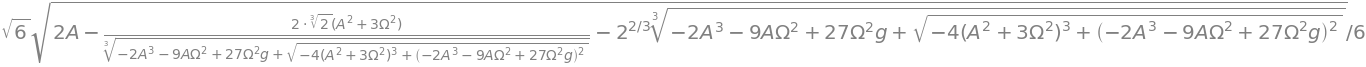

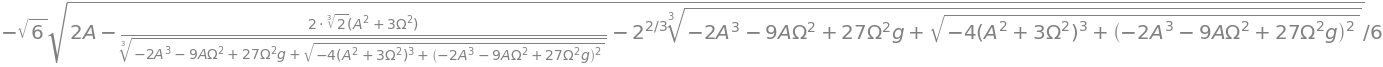

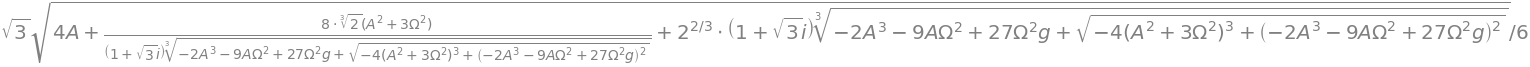

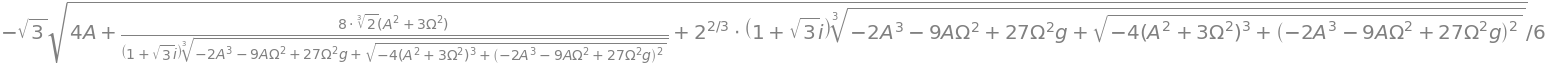

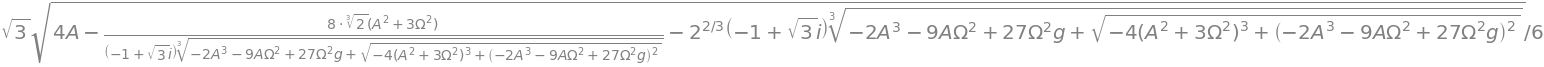

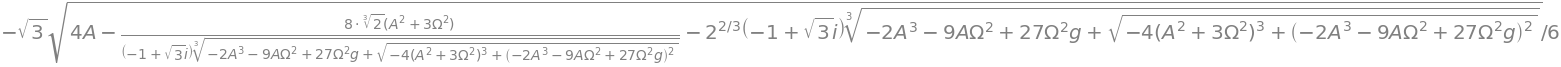

In [1]:
import sympy as sp

# Define symbols
A, Omega, g, x = sp.symbols('A Omega g x', complex=True)

# Define the cubic equation in terms of x (where x = k^2)
cubic_eq = x**3 - A*x**2 - Omega**2*x + Omega**2*g

# Solve for x symbolically
x_roots = sp.solve(cubic_eq, x)

# Compute k values (square roots of x)
k_roots = []
for x_i in x_roots:
    sqrt_xi = sp.sqrt(x_i)  # Principal square root
    k_roots.append(sqrt_xi)
    k_roots.append(-sqrt_xi)  # Include negative sqrt

# Display results in a readable format
sp.init_printing()  # For better display in Jupyter Notebook

print("Roots of k (symbolic):")
for i, k in enumerate(k_roots):
    display(sp.simplify(k))  # Simplify and display each root


Numerical Roots of k:


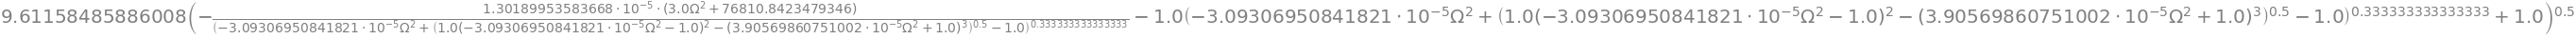

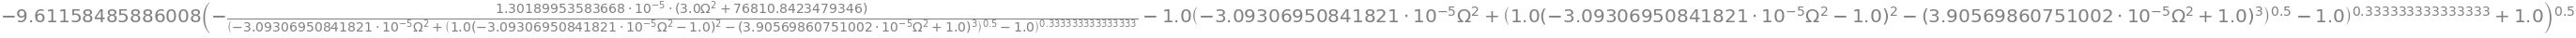

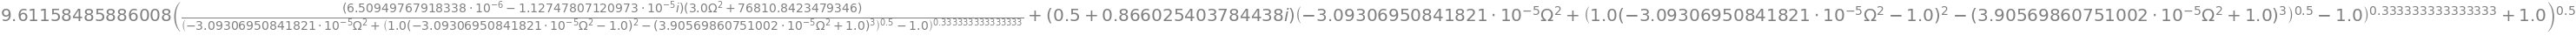

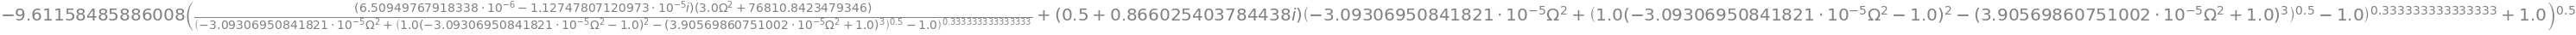

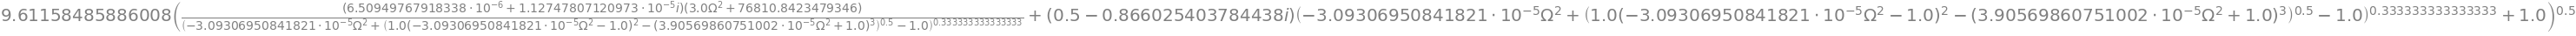

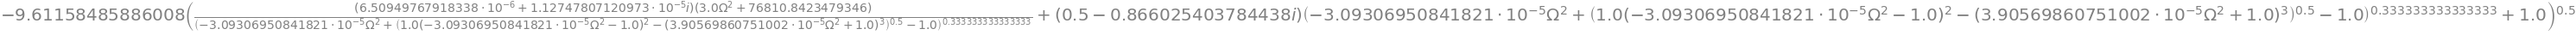

In [3]:
import sympy as sp
import numpy as np
# Define inputs
L = 0.1
rho1 = 7850
rho3 = rho1
E1 = 206e9
E3 = E1

rho2 = 2600
eta2 = 0.1
G2 = 0.98e10

b = 0.05 #this is not given in the paper. check if it affects anything. 
h1 = 0.003 / 2
h2 = 0.005 /2
h3 = 0.008 / 2

# Calculate parameters
I1 = b*(h1*2)**3 / 12
I3 = b*(h3*2)**3 / 12
A1 = b*h1*2
A2 = b*h2*2
A3 = b*h3*2

D = E1*I1+E3*I3
m = rho1*A1 + rho2*A2 + rho3*A3 # mass per unit length of beam
t0 = np.sqrt(m*L**4/D)
G2_ = G2*(1+1j*eta2)
g_ = (G2*A2*L**2 / 4/h2**2) * ((E1*A1+E3*A3)/(E1*A1*E3*A3))
g = g_.real
c = 2*h2 + h1+ h3 
Y = c**2/D * ((E1*A1*E3*A3)/(E1*A1+E3*A3))

# Define symbols
A, Omega, g, x = sp.symbols('A Omega g x', complex=True)

# Define the cubic equation
cubic_eq = x**3 - A*x**2 - Omega**2*x + Omega**2*g

# Solve for x symbolically
x_roots = sp.solve(cubic_eq, x)

# Compute k values (square roots of x)
k_roots = []
for x_i in x_roots:
    sqrt_xi = sp.sqrt(x_i)  # Principal square root
    k_roots.append(sqrt_xi)
    k_roots.append(-sqrt_xi)  # Include negative sqrt

# Substitute values for A, Omega, and g
A_value = g_*(1+ Y) 
g_value = g_

# Create substitutions dictionary
subs_dict = {A: A_value, g: g_value}

# Compute numerical values for k
numerical_k = [k.subs(subs_dict).evalf() for k in k_roots]

# Display results
sp.init_printing()  # For better formatting in Jupyter

print("Numerical Roots of k:")
for i, k in enumerate(numerical_k):
    display(k)  # Show each substituted root
